Based on code in https://github.com/anshu957/OrderChaosHNN/tree/master

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datetime import datetime


from scripts.networks import sympNet, genericNet
from scripts.utils import *
from scripts.training import trainModel, trainingSupervised
from scripts.sampling import sample_ic, generateDataSupervised, createDatasetSupervised
from scripts.plotting import *
from scripts.experiments import *
from scripts.vector_fields import *
import scripts.settings as settings
from tqdm import tqdm
import glob
import time as time_lib

In [2]:
def get_poincare_section(orbit):
    '''
        Takes in an orbit (x,y,x_dot,y_dot) and spits out a Poincaré section (y,y_dot) as a tuple.
    '''
    x, y, x_dot, y_dot = orbit[0], orbit[1], orbit[2], orbit[3]
    y_poincare = []
    y_dot_poincare = []
    for i in range(len(x) - 1):
        if (x[i] * x[i + 1] < 0.0):
            y_poincare.append(0.5 * (y[i] + y[i + 1]))
            y_dot_poincare.append(0.5 * (y_dot[i] + y_dot[i + 1]))

    return y_poincare, y_dot_poincare

In [3]:
def get_random_intial_conditons(energy):
    result = False
    while not result:
        with np.errstate(invalid='raise'):
            try:
                q1, q2 = 0.3*(1-2*np.random.random(2))
                p1= 0.2*(1-2*np.random.random())
                p2 = abs(np.sqrt(2*(energy - (q1**2*q2 - q2**3/3.0))-(q1**2+q2**2+p1**2)))
                result = True 
            except FloatingPointError:
                continue 

    initial_state = np.array([q1, q2, p1, p2])
    return initial_state

In [4]:
def solution_scipy(y0,t_eval,vec):
    
    #This method computes the approximate solution starting from y0
    #over the time interval t_eval of the vector field vec using a BDF
    #method from the Scipy library.
    
    def fun(t,y):
        q,p = y[:vec.ndim_total//2],y[vec.ndim_total//2:]
        if(not vec.isa_doubled_variables_system):
            q = torch.tensor(q).unsqueeze(0)
            p = torch.tensor(p).unsqueeze(0)
            q_grad,p_grad = vec.eval_vec_field(q,p)
            return np.concatenate([q_grad.squeeze(0).numpy(),p_grad.squeeze(0).numpy()],axis=0)
        elif vec.system_parameters['system']=="damped-harmonic-oscillator": 
            q,p = y[:vec.ndim_total//4],y[vec.ndim_total//4:]
            return np.concatenate([p/vec.m,-vec.ll/vec.m*p-vec.k*q],axis=0)
        else:
            print("Dynamics not implemented")
    
    t_span = [t_eval[0],t_eval[-1]]
    res = solve_ivp(fun, t_span=t_span, t_eval=t_eval, y0=y0, method='RK45',rtol=1e-12)
    return res.y,res.t

In [5]:
system_parameters = Henon_Heiles_exp #SimpleHO_exp #
vector_field_class = globals()[system_parameters["vec_field_name"]]
vec = vector_field_class(system_parameters)

In [6]:
def get_last_trained_model(path):
    # Get the list of all files matching the pattern
    files = glob.glob(os.path.join(path, "trained_model_*.pt"))

    # Function to extract the timestamp from the filename
    def extract_timestamp(filename):
        basename = os.path.basename(filename)
        timestamp_str = basename[len("trained_model_"):-len(".pt")]
        return datetime.strptime(timestamp_str, "%Y%m%d_%H%M%S")

    # Find the latest file by comparing timestamps
    latest_file_name = max(files, key=extract_timestamp)
    return latest_file_name

In [15]:
is_supervised = input("Do you want the plots for the supervised experiment? Type y for yes, any other key for the unsupervised")=="y"
save_path = "supervisedNetworks/" if is_supervised else "unsupervisedNetworks/" 
model_path = save_path + "savedModels/"
figure_path = save_path + 'figures/'
losses_path = save_path + "losses/"

system_parameters = Henon_Heiles_exp
vector_field_class = globals()[system_parameters['vec_field_name']]
vec = vector_field_class(system_parameters)
settings.paths = dict(
    model = model_path,
    figure = figure_path,
    losses = losses_path
    )

print(settings.paths['model'])

unsupervisedNetworks/savedModels/


In [16]:
torch.manual_seed(1)
np.random.seed(1)
dtype=torch.float32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
training_parameters = dict(
    dt=1.0,
    tf=10,
    t0=-0.1,
    n_train=700,
    n_test=5000,
    epochs=10001,
    device=device,
    dtype=dtype,
    lr = 5e-3
)

ode_name = "HenonHeiles"

model_parameters = dict(
    hidden_nodes = 10,
    act_name = 'tanh',
    nlayers = 3,
    device=device,
    dtype=dtype,
    d=vec.ndim_total
)

In [20]:
name_experiment = "pinn" if is_supervised else "pinnReg"
path = f"{settings.paths['model']}/{ode_name}/{name_experiment}"
model_path = get_last_trained_model(path) #it appends the latest time stamp
print(model_path)
model_pinn = genericNet(model_parameters,vec=vec, dt=training_parameters['dt']) #Usual network
model_pinn.load_state_dict(torch.load(model_path,map_location=device),strict=True)
model_pinn.to(device);

name_experiment = "sympflow" if is_supervised else "hamReg"
path = f"{settings.paths['model']}/{ode_name}/{name_experiment}"
model_path = get_last_trained_model(path) #it appends the latest time stamp
print(model_path)
model_sympflow = sympNet(model_parameters,vec=vec, dt=training_parameters['dt']) #Symplectic network
model_sympflow.load_state_dict(torch.load(model_path,map_location=device),strict=True)
model_sympflow.to(device);

unsupervisedNetworks/savedModels//HenonHeiles/pinnReg/trained_model_20250604_175536.pt
unsupervisedNetworks/savedModels//HenonHeiles/hamReg/trained_model_20250604_222437.pt


In [21]:
def approximate_solution(y0, model, t0, tf, fine_resolution, dtype, device):
    with torch.no_grad():

        d = len(y0)
        dt = model.dt

        tf = (tf//dt)*dt #to make sure we end at a multiple of dt

        num_intervals = int((tf - t0) / dt) 
        ref_interval = torch.linspace(0, dt, fine_resolution, device=device)[1:]  # 10 sub-steps
        jump = len(ref_interval)

        # Total solution storage, starting with initial condition
        sol = torch.zeros((num_intervals * jump + 1, d), dtype=dtype, device=device)
        sol[0] = y0
        time = torch.linspace(t0, tf, jump * num_intervals + 1, device=device)

        # Prepare initial conditions and times for parallel fill-in
        intermediate_sols = torch.zeros((num_intervals, d), device=device)
        intermediate_sols[0] = y0

        # Step 1: Sequentially calculate values at multiples of dt
        for i in range(1, num_intervals):
            intermediate_sols[i] = model(intermediate_sols[i - 1:i], torch.tensor([[dt]], dtype=dtype).to(device))
        # Step 2: Parallel fill for sub-intervals
        times_global = torch.kron(torch.ones(num_intervals, device=device), ref_interval)#.view(-1, 1)
        initial_conditions = intermediate_sols.repeat_interleave(jump, dim=0)
        # Perform parallel model predictions and store in sol
        predictions = model(initial_conditions, times_global)
        sol[1:] = predictions  # Fill the solution with parallel predictions directly
    return sol, time

In [22]:
# calculates 'n' different true orbits corresponding to the same energy
n_orbits = 10
np.random.seed(13353)
energy = 0.1
orbit_set = []
tspan = [0, 4000]
time_points = 400000
t_eval = np.linspace(tspan[0], tspan[1], time_points+1)
external_update_fn = None

ics = []

for i in tqdm(range(n_orbits)):
    y0 = get_random_intial_conditons(energy)
    ics.append(y0)
    sol, t = solution_scipy(y0,t_eval,vec)
    orbit_set.append(sol)

100%|██████████| 10/10 [00:50<00:00,  5.02s/it]


In [23]:
# calculates 'n' different learned-hnn orbits corresponding to the same energy
baseline_orbit_set = []
np.random.seed(13353)

for i in tqdm(range(n_orbits)):
    #y0 = get_random_intial_conditons(energy)
    y0 = ics[i]
    sol, t = approximate_solution(
        y0 = torch.from_numpy(y0.astype(np.float32)),
        model=model_pinn,
        t0=t_eval[0],
        tf=t_eval[-1],
        fine_resolution=101,
        dtype=dtype,
        device=device
    )
    sol = sol.T.detach().cpu().numpy()
    t = t.detach().cpu().numpy()
    baseline_orbit_set.append(sol)

100%|██████████| 10/10 [00:02<00:00,  4.40it/s]


In [24]:
# calculates 'n' different learned-hnn orbits corresponding to the same energy
sympflow_orbit_set = []
np.random.seed(13353)

for i in tqdm(range(n_orbits)):
    #y0 = get_random_intial_conditons(energy)
    y0 = ics[i]
    t = t_eval
    sol, t = approximate_solution(
        y0 = torch.from_numpy(y0.astype(np.float32)),
        model=model_sympflow,
        t0=t_eval[0],
        tf=t_eval[-1],
        fine_resolution=101,
        dtype=dtype,
        device=device
    )
    sol = sol.T.detach().cpu().numpy()
    t = t.detach().cpu().numpy()
    sympflow_orbit_set.append(sol)

100%|██████████| 10/10 [03:04<00:00, 18.46s/it]


In [25]:
# get the poincare sections for corresponding true orbits 
y = []
y_dot = []
for i in range(n_orbits):
    y_tmp, y_dot_tmp = get_poincare_section(orbit_set[i])
    y.append(y_tmp)
    y_dot.append(y_dot_tmp)

In [26]:
# get the poincare sections for corresponding sympflow orbits 
sympflow_y = []
sympflow_y_dot = []
for i in range(n_orbits):
    y_tmp, y_dot_tmp = get_poincare_section(sympflow_orbit_set[i])
    sympflow_y.append(y_tmp)
    sympflow_y_dot.append(y_dot_tmp)

In [27]:
# get the poincare sections for corresponding baseline orbits 
baseline_y = []
baseline_y_dot = []
for i in range(n_orbits):
    y_tmp, y_dot_tmp = get_poincare_section(baseline_orbit_set[i])
    baseline_y.append(y_tmp)
    baseline_y_dot.append(y_dot_tmp)

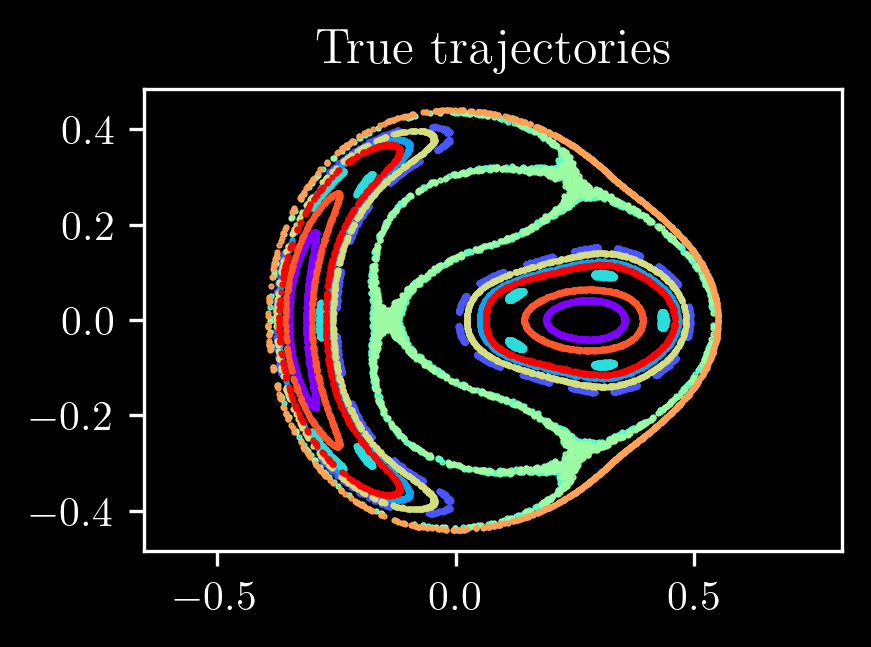

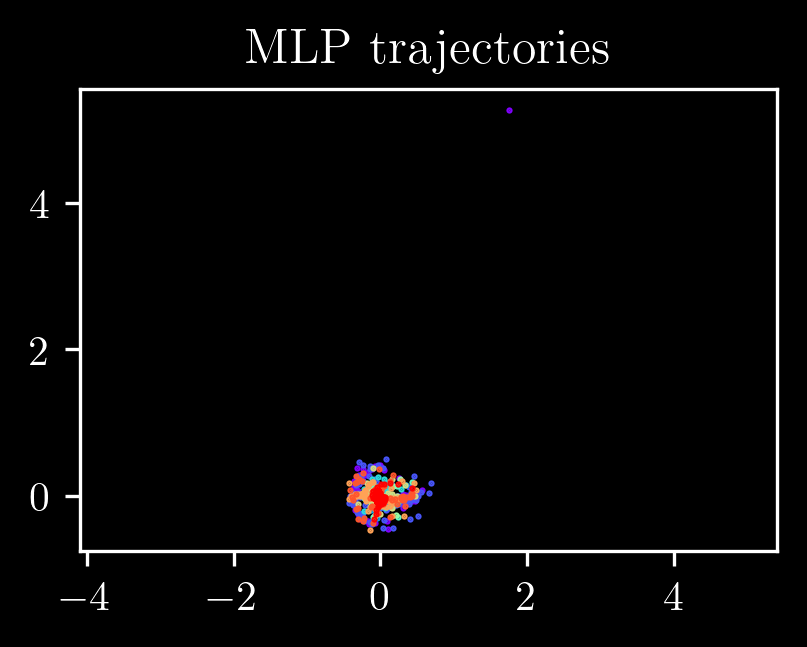

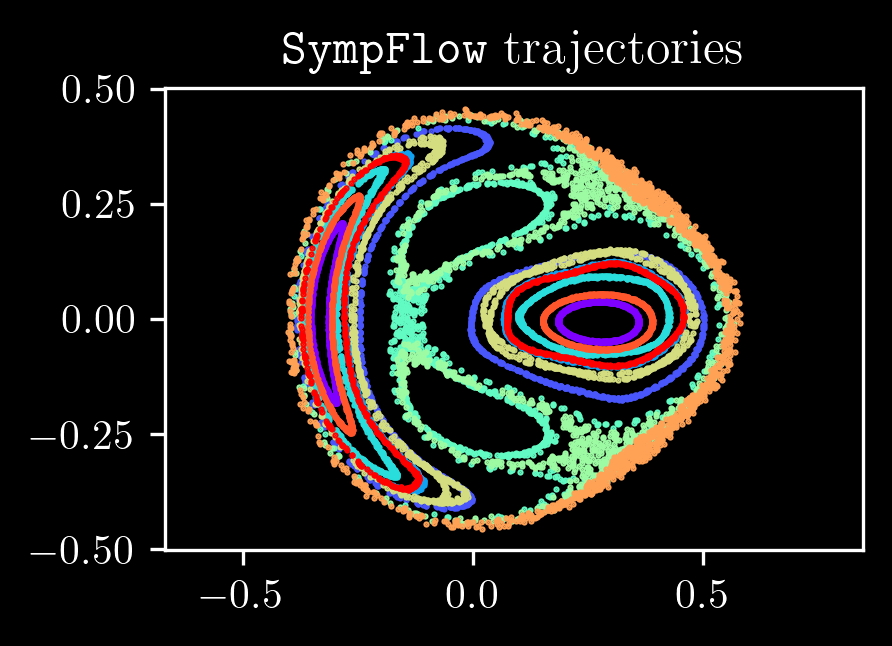

In [44]:
import matplotlib
from matplotlib import cm

plt.rcParams["figure.dpi"] = 300
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 10

#plt.style.use('dark_background')
plt.rcParams["figure.figsize"] = (3,2)

colors = matplotlib.cm.rainbow(np.linspace(0, 1, n_orbits))
fig = plt.figure()

plt.title('True trajectories')
for i in range(n_orbits):
    plt.plot(y[i], y_dot[i], '.', markersize=1, color=colors[i])
plt.axis('equal')

fig = plt.figure()
plt.title('MLP trajectories')
for i in range(n_orbits):
    plt.plot(baseline_y[i], baseline_y_dot[i], '.', markersize=1, color=colors[i])
plt.axis('equal')

fig = plt.figure()
plt.title(r'$\texttt{SympFlow}$ trajectories')
for i in range(n_orbits):
    plt.plot(sympflow_y[i], sympflow_y_dot[i], '.', markersize=1, color=colors[i])
plt.axis('equal')

if not os.path.exists("poincareSections"):
    os.mkdir("poincareSections")

supervised = "supervised" if is_supervised else "unsupervised"
timestamp = time_lib.strftime("%Y%m%d_%H%M%S")
plt.savefig(f"poincareSections/poincareSection_{supervised}_{timestamp}.pdf",bbox_inches='tight')
plt.show()